# Problem Classes and Scaling Intuition

**Motivating question:** When does a problem stop feeling large and start feeling impossible?

**Learning goals**
- connect explosive growth to brute-force search spaces
- see why finding a solution can be much harder than checking one
- build an intuitive map of `P` (Polynomial-time solvable), `NP` (Nondeterministic polynomial-time), `NP-hard`, and `NP-complete`
- form a careful bridge from classical complexity language to `BPP` (Bounded-error probabilistic polynomial time) and `BQP` (Bounded-error quantum polynomial time)
- avoid the common mistake that quantum computing makes every hard problem easy

*This notebook accompanies Lecture 03 on computational complexity. It is designed for live demo and self-study.*


In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / 'utilities' / 'complexity_utils.py').exists():
        ROOT = candidate
        break
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown

from utilities.complexity_utils import (
    display_wrapped,
    instructor_prompt,
    markdown_box,
    plot_bounded_error_amplification,
    plot_claim_checklist,
    plot_growth_story,
    plot_problem_class_map,
    plot_search_space_growth,
    plot_subset_sum_workflow,
    setup_lecture_style,
    timed_call,
)

setup_lecture_style()
rng = np.random.default_rng(42)
pd.options.display.float_format = lambda value: f'{value:,.3g}'


This notebook follows the shared Lecture 03 visual rhythm: a motivating question, a small model, one dominant visual, a compact comparison, and a short takeaway.

This notebook steps back from individual data structures and algorithms. The earlier notebooks focused on how cost changes inside a computation; this one organizes whole families of problems by how their search spaces and verification costs scale.

## 1. When does growth become impossible?

**Concept question:** At what point does “just try everything” stop being a serious plan?


In [2]:
# We reuse a small set of growth laws so students can compare them on the same x-axis.
n_values = np.arange(1, 13)
growth_series = {
    'n': n_values,
    'n log₂ n': n_values * np.log2(np.maximum(n_values, 2)),
    'n²': n_values ** 2,
    '2ⁿ': 2.0 ** n_values,
    'n!': np.array([math.factorial(int(n)) for n in n_values], dtype=float),
}


We start with the simplest possible comparison: a few familiar growth laws on the same axis. The exact formulas matter less than the shape. The goal is to train the eye to notice when growth is still negotiable and when it is already becoming unrealistic.


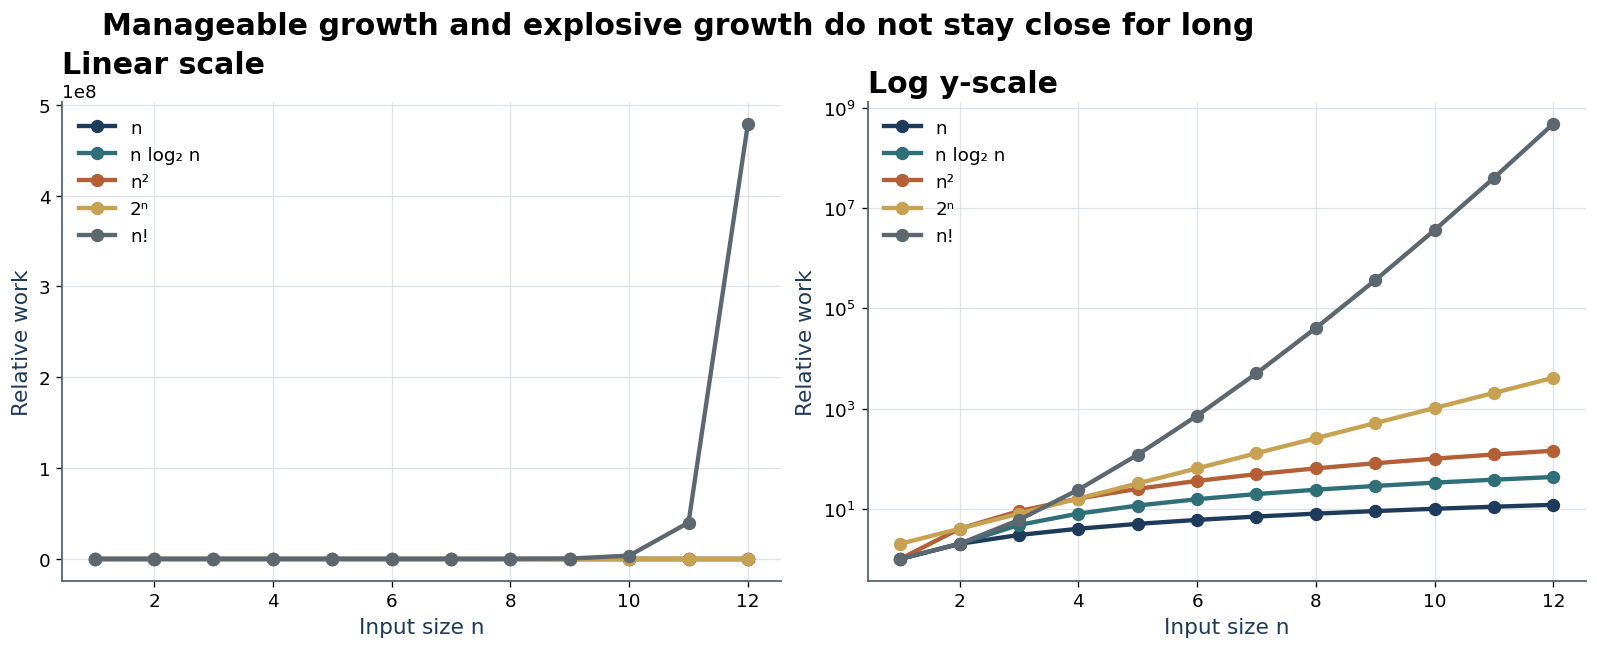

In [3]:
plot_growth_story(
    n_values,
    growth_series,
    title='Manageable growth and explosive growth do not stay close for long',
)
plt.show()


Polynomial curves certainly grow, but exponential and factorial growth detach very quickly. On the log-scaled panel, the shapes are still visible after the linear panel has already been dominated by the explosive cases.


In [4]:
representative_sizes = [4, 8, 12, 16, 20]
growth_table = pd.DataFrame(
    {
        'n': representative_sizes,
        'n²': [n ** 2 for n in representative_sizes],
        '2ⁿ': [2 ** n for n in representative_sizes],
        'n!': [math.factorial(n) for n in representative_sizes],
    }
)
display_wrapped(growth_table)


,n,n²,2ⁿ,n!
0,4,16,16,24
1,8,64,256,40320
2,12,144,4096,479001600
3,16,256,65536,20922789888000
4,20,400,1048576,2432902008176640000


The small table below gives anchor values. Students often understand the curves more clearly after seeing a few concrete numbers side by side, especially once factorial growth enters the picture.


In [ ]:
def enumerate_all_subset_sums(values):
    """Brute force: inspect every subset and record its sum."""
    subset_sums = []
    n = len(values)
    # 1 << 0 = 1      # 0001
    # 1 << 1 = 2      # 0010
    # 1 << 2 = 4      # 0100
    # 1 << 3 = 8      # 1000
    for mask in range(1 << n):
        total = 0
        for bit_index, value in enumerate(values):
            # & is a bitwise operator that checks if the bit at bit_index is set in mask.
            # example mask = 5 (0101 in binary) and bit_index = 0, then (1 << bit_index) is 1 (0001 in binary).
            if mask & (1 << bit_index):
                total += value
        subset_sums.append(total)
    return subset_sums


subset_sizes = [4, 8, 12, 16, 20]
subset_space_df = pd.DataFrame(
    {
        'items': subset_sizes,
        'candidate subsets': [2 ** n for n in subset_sizes],
        'seconds at 1,000,000 checks/s': [2 ** n / 1_000_000 for n in subset_sizes],
    }
)


**Subset enumeration task.** Given a list `values` of length `n`, enumerate every subset that can be formed from those items and compute the sum of each subset.

In the code, each subset is encoded by one integer `mask` between `0` and `2^n - 1`. The loop variable `bit_index` asks whether the item at that position is included in the current subset. If the corresponding bit in `mask` is `1`, that `value` contributes to the running `total`.

**Key aspects to notice:**
- `n = len(values)` is the number of available decisions.
- each `mask` represents one candidate subset.
- there are `2^n` possible masks, so the number of candidates doubles whenever `n` increases by 1.
- computing `total` for one mask is cheap, but repeating that work over all masks becomes expensive very quickly.

This is why subset enumeration is a clean model of combinatorial explosion: the work grows because the number of possible choices grows explosively.


Now we turn that abstract growth picture into a concrete brute-force story. Subset enumeration is a good teaching example because every new item creates one more binary choice: include it or do not include it.


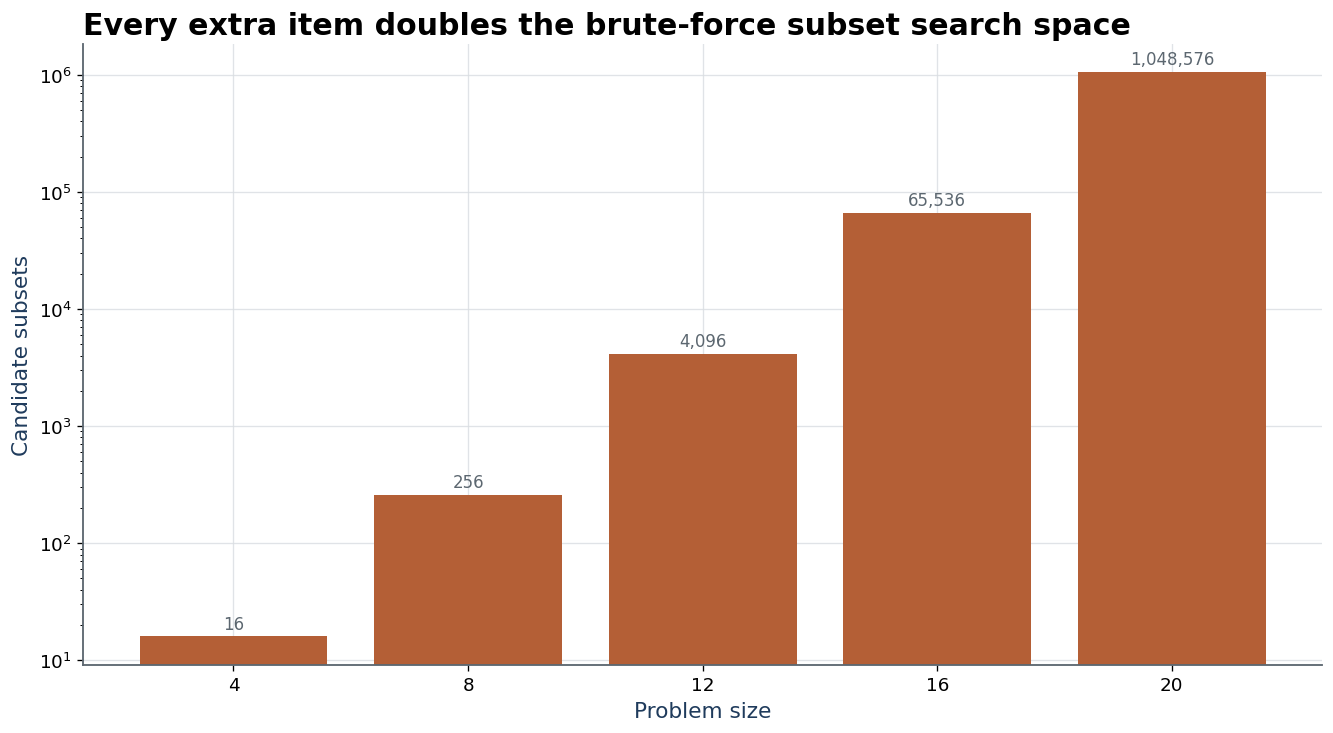

In [6]:
plot_search_space_growth(
    subset_space_df['items'],
    subset_space_df['candidate subsets'],
    title='Every extra item doubles the brute-force subset search space',
    ylabel='Candidate subsets',
)
plt.show()


In [7]:
subset_space_df['human reading'] = [
    'instant',
    'instant',
    'small but noticeable',
    'already heavy in Python',
    'about one second at 1M checks/s',
]
display_wrapped(subset_space_df)


,items,candidate subsets,"seconds at 1,000,000 checks/s",human reading
0,4,16,1.6e-05,instant
1,8,256,0.000256,instant
2,12,4096,0.0041,small but noticeable
3,16,65536,0.0655,already heavy in Python
4,20,1048576,1.05,about one second at 1M checks/s


In [8]:
subset_runtime_rows = []
for num_items in [8, 10, 12, 14, 16]:
    values = list(range(1, num_items + 1))
    _, stats = timed_call(enumerate_all_subset_sums, values, repeat=1, warmup=0)
    subset_runtime_rows.append(
        {
            'items': num_items,
            'candidate subsets': 2 ** num_items,
            'measured time (ms)': 1000 * stats['mean_s'],
        }
    )

subset_runtime_df = pd.DataFrame(subset_runtime_rows)
display_wrapped(subset_runtime_df)


,items,candidate subsets,measured time (ms)
0,8,256,0.134
1,10,1024,0.593
2,12,4096,2.88
3,14,16384,12.8
4,16,65536,58


In [9]:
display_wrapped(Markdown(markdown_box(
    'Explosion is not a metaphor here. In brute force, each extra binary choice doubles the search space. That is why some problems move from easy to impossible very quickly.'
)))


> **Takeaway:**
> Explosion is not a metaphor here. In brute force, each extra binary choice doubles the search space. That is why some problems move from easy to impossible very quickly.

In [10]:
display_wrapped(Markdown(instructor_prompt(
    'If your search space doubles every time you add one more decision, how many extra decisions can you really afford before the plan breaks down?'
)))


> **Instructor Prompt:**
> If your search space doubles every time you add one more decision, how many extra decisions can you really afford before the plan breaks down?

## 2. Searching vs verifying

**Concept question:** Why can checking one proposed answer feel cheap even when finding that answer feels expensive?


In [11]:
def verify_subset_sum(numbers, candidate_mask, target):
    """Check one proposed subset by scanning the candidate mask once."""
    chosen_numbers = []
    total = 0
    inspected_positions = 0
    for number, keep in zip(numbers, candidate_mask):
        inspected_positions += 1
        if keep:
            chosen_numbers.append(number)
            total += number
    return {
        'is_valid': total == target,
        'total': total,
        'chosen_numbers': chosen_numbers,
        'inspected_positions': inspected_positions,
    }


def brute_force_subset_sum(numbers, target):
    """Search all subset masks until a valid subset appears or the search space ends."""
    n = len(numbers)
    candidates_checked = 0
    for mask in range(1 << n):
        candidate_mask = [bool((mask >> bit_index) & 1) for bit_index in range(n)]
        report = verify_subset_sum(numbers, candidate_mask, target)
        candidates_checked += 1
        if report['is_valid']:
            report['candidate_mask'] = candidate_mask
            report['candidates_checked'] = candidates_checked
            return report
    return {
        'is_valid': False,
        'candidate_mask': None,
        'chosen_numbers': [],
        'total': None,
        'inspected_positions': n,
        'candidates_checked': candidates_checked,
    }


solve_numbers = [4, 7, 11, 13, 18, 21, 25, 30]
solve_target = 42
solve_candidate_mask = [True, False, False, True, False, False, True, False]

verify_report = verify_subset_sum(solve_numbers, solve_candidate_mask, solve_target)
search_report = brute_force_subset_sum(solve_numbers, solve_target)


This section uses a subset-sum-style toy problem. The search procedure tries candidate subsets until one works. The verification procedure assumes a candidate was already proposed and only checks whether that candidate is correct.


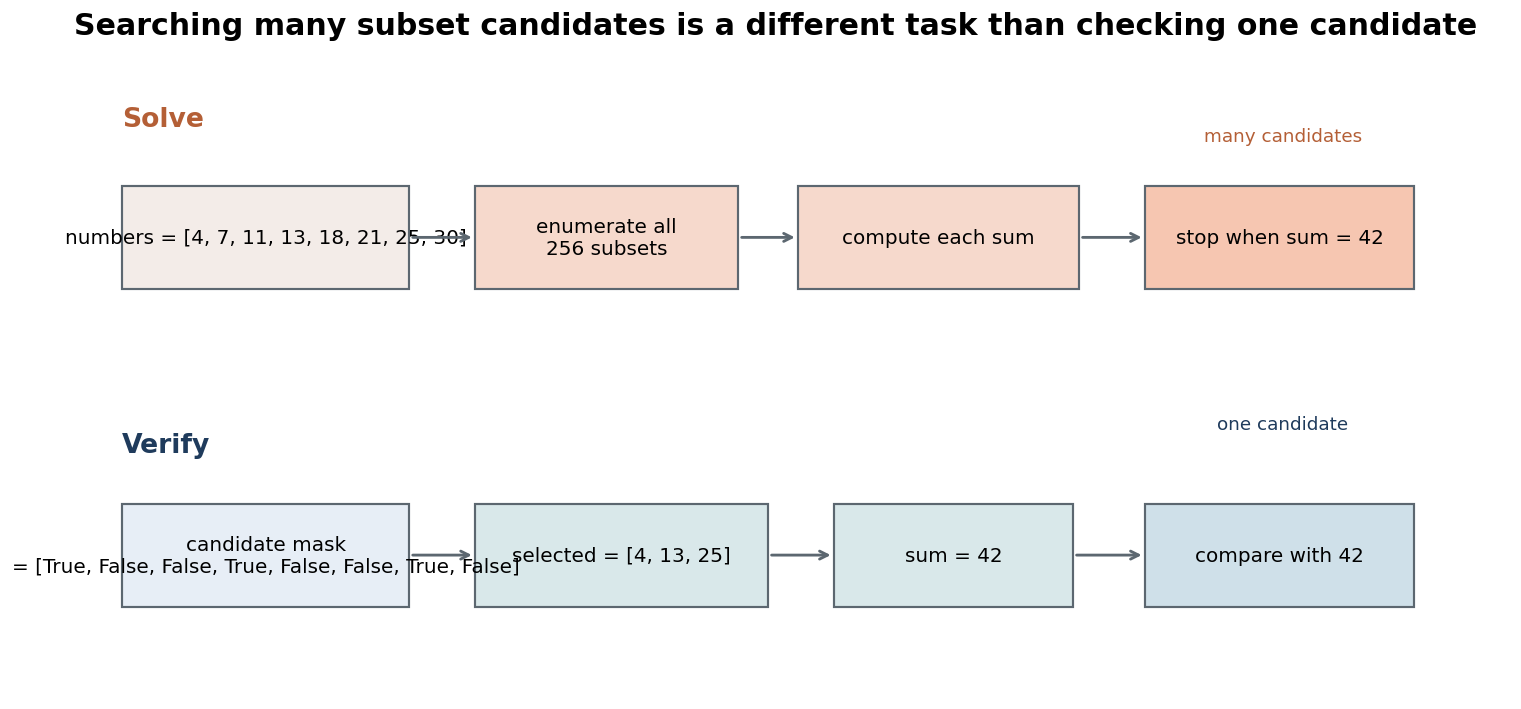

In [12]:
plot_subset_sum_workflow(
    solve_numbers,
    solve_candidate_mask,
    solve_target,
    title='Searching many subset candidates is a different task than checking one candidate',
)
plt.show()


Verification does not need to be magical. It only needs one candidate to inspect. Search has to discover that candidate, and brute force may need to inspect many of them before it succeeds.


In [13]:
search_vs_verify_df = pd.DataFrame(
    {
        'Task': ['Verify one proposed subset', 'Brute-force search for a valid subset'],
        'Work on this example': [
            f"inspect {verify_report['inspected_positions']} positions once",
            f"checked {search_report['candidates_checked']} candidates before success",
        ],
        'Scaling intuition': ['about n steps', 'up to 2ⁿ candidate masks'],
    }
)
display_wrapped(search_vs_verify_df)


,Task,Work on this example,Scaling intuition
0,Verify one proposed subset,inspect 8 positions once,about n steps
1,Brute-force search for a valid subset,checked 28 candidates before success,up to 2ⁿ candidate masks


The comparison table below is the conceptual heart of the section. One row is about checking a single candidate. The other row is about discovering a candidate in the first place. Those are different computational tasks, even when they talk about the same problem.


In [14]:
search_verify_rows = []
for num_items in [6, 8, 10, 12, 14]:
    numbers = list(range(2, 2 + num_items))
    impossible_target = sum(numbers) + 1
    one_candidate = [False] * num_items

    _, search_stats = timed_call(brute_force_subset_sum, numbers, impossible_target, repeat=1, warmup=0)
    _, verify_stats = timed_call(verify_subset_sum, numbers, one_candidate, impossible_target, repeat=200, warmup=5)

    search_verify_rows.append(
        {
            'items': num_items,
            'search candidates in worst case': 2 ** num_items,
            'verify positions scanned': num_items,
            'search time (ms)': 1000 * search_stats['mean_s'],
            'verify time (ms)': 1000 * verify_stats['mean_s'],
        }
    )

search_verify_runtime_df = pd.DataFrame(search_verify_rows)
display_wrapped(search_verify_runtime_df)


,items,search candidates in worst case,verify positions scanned,search time (ms),verify time (ms)
0,6,64,6,0.0702,0.00037
1,8,256,8,0.298,0.000516
2,10,1024,10,1.36,0.000404
3,12,4096,12,6.04,0.000475
4,14,16384,14,26.8,0.000515


In [15]:
display_wrapped(Markdown(markdown_box(
    'Easy to verify does not imply easy to find. That distinction is the doorway into the language of problem classes.'
)))


> **Takeaway:**
> Easy to verify does not imply easy to find. That distinction is the doorway into the language of problem classes.

In [16]:
display_wrapped(Markdown(instructor_prompt(
    'If I hand you a candidate answer, can you check it much faster than you could have discovered it yourself?'
)))


> **Instructor Prompt:**
> If I hand you a candidate answer, can you check it much faster than you could have discovered it yourself?

## 3. Problem classes as a map

**Concept question:** If some problems are easy to solve, some are easy to check, and some seem explosively hard, how do we organize that landscape?

We now step back from one example and ask a classification question. In the subset problem above, brute-force search had to explore many candidate subsets, while verification only needed to inspect one proposed subset. Problem classes give us language for exactly that kind of distinction.


In [17]:
class_rows = [
    {
        'Class': 'P (Polynomial-time solvable)',
        'Intuition': 'We know algorithms that solve these problems efficiently.',
        'Course-friendly example': 'searching in sorted data, shortest paths, sorting',
    },
    {
        'Class': 'NP (Nondeterministic polynomial-time)',
        'Intuition': 'A proposed solution can be checked efficiently.',
        'Course-friendly example': 'subset-sum candidate checking, SAT assignment checking',
    },
    {
        'Class': 'NP-hard (at least as hard as the hardest problems in NP)',
        'Intuition': 'At least as hard as the hardest problems in NP; may not even be in NP.',
        'Course-friendly example': 'optimization versions of routing or scheduling',
    },
    {
        'Class': 'NP-complete (in NP and NP-hard)',
        'Intuition': 'Problems inside NP that are also NP-hard.',
        'Course-friendly example': 'decision versions of SAT and many combinatorial puzzles',
    },
]


The next visual is intentionally not a theorem diagram. It is a course-level map. Each class is introduced through the type of claim it makes about solving, checking, or hardness.

Keep the subset example in mind while reading it:

- if a problem behaves like our search examples from notebook 1, we hope it might sit in `P` (Polynomial-time solvable)
- if a problem behaves like subset-sum checking, it fits the intuition behind `NP` (Nondeterministic polynomial-time)
- if a problem seems to inherit the difficulty of the hardest search problems, we start talking about `NP-hard`
- if a problem is both efficiently checkable and as hard as the hardest problems in `NP`, we call it `NP-complete`


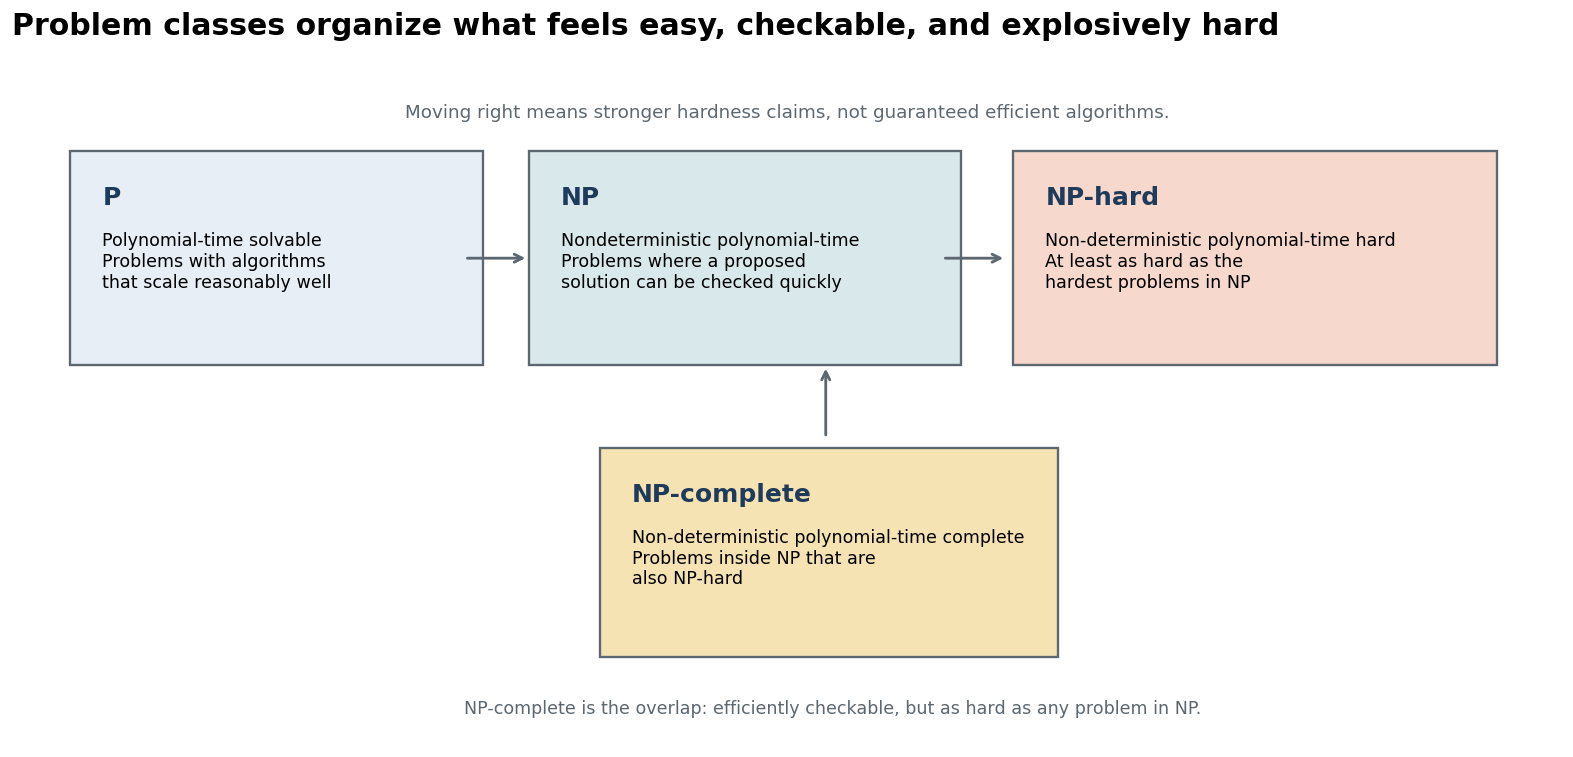

In [18]:
plot_problem_class_map(
    title='Problem classes organize what feels easy, checkable, and explosively hard',
)
plt.show()


The map is about relationships and expectations, not about memorizing slogans. `P` (Polynomial-time solvable) describes problems we know how to solve efficiently, while `NP` (Nondeterministic polynomial-time) highlights the difference between solving and checking.

For the subset problem, the important lesson is this:

- checking one proposed subset against a target is the kind of task that motivates the intuition for `NP`
- searching through all possible subsets is the kind of task that makes brute force explode


In [19]:
class_df = pd.DataFrame(class_rows)
display_wrapped(class_df)


,Class,Intuition,Course-friendly example
0,P (Polynomial-time solvable),We know algorithms that solve these problems efficiently.,"searching in sorted data, shortest paths, sorting"
1,NP (Nondeterministic polynomial-time),A proposed solution can be checked efficiently.,"subset-sum candidate checking, SAT assignment checking"
2,NP-hard (at least as hard as the hardest problems in NP),At least as hard as the hardest problems in NP; may not even be in NP.,optimization versions of routing or scheduling
3,NP-complete (in NP and NP-hard),Problems inside NP that are also NP-hard.,decision versions of SAT and many combinatorial puzzles


After the class map, the tables make two things explicit: what each label means intuitively and why the same growth law does not apply to every problem family in the same way.


In [20]:
class_scaling_df = pd.DataFrame(
    {
        'Toy lens': ['Polynomial-style work', 'Subset-style search', 'Route-ordering search'],
        'Representative expression': ['n²', '2ⁿ', 'n!'],
        'size 10': [10 ** 2, 2 ** 10, math.factorial(10)],
        'size 20': [20 ** 2, 2 ** 20, math.factorial(20)],
    }
)
display_wrapped(class_scaling_df)


,Toy lens,Representative expression,size 10,size 20
0,Polynomial-style work,n²,100,400
1,Subset-style search,2ⁿ,1024,1048576
2,Route-ordering search,n!,3628800,2432902008176640000


In [21]:
display_wrapped(Markdown(markdown_box(
    'Problem classes do not tell the whole story, but they give us a disciplined vocabulary for solveable, checkable, and apparently intractable behavior.'
)))


> **Takeaway:**
> Problem classes do not tell the whole story, but they give us a disciplined vocabulary for solveable, checkable, and apparently intractable behavior.

In [22]:
display_wrapped(Markdown(instructor_prompt(
    'If two problems both look hard at first glance, what extra information would you want before claiming they belong in the same class?'
)))


> **Instructor Prompt:**
> If two problems both look hard at first glance, what extra information would you want before claiming they belong in the same class?

## 4. A cautious bridge to randomness and quantum

**Concept question:** If we allow randomness or quantum effects, what changes in the map and what does not?


**What are the “algorithms” in this section?** We are not studying a concrete quantum algorithm here. Instead, we study a very simple **bounded-error computation model**. Imagine a procedure that tries to answer a decision problem and is correct more often than it is wrong. One run may fail, but repeated runs can be combined by majority vote.

This section explores two related procedures:

- `majority_vote_error_probability(single_run_error, repeats)` computes the error probability **exactly** using combinatorics. It answers the question: if one run is wrong with probability `single_run_error`, how likely is a majority of `repeats` runs to still be wrong?
- `simulate_majority_vote_error(single_run_error, repeats, trials, rng)` estimates the same quantity by **simulation**. It repeatedly samples noisy runs and measures how often the majority vote fails.

Why is this relevant here? Because classes such as `BPP` (Bounded-error probabilistic polynomial time) and `BQP` (Bounded-error quantum polynomial time) allow algorithms with a **bounded probability of error**. The point of this section is to build intuition for that phrase before later lectures talk about randomized and quantum algorithms more concretely.


In [23]:
# We now study an abstract bounded-error procedure.
# Think of one run as a black-box algorithm that returns the correct answer
# most of the time, but can still fail with probability `single_run_error`.
# The question is: if we repeat that procedure several times and use
# majority vote, how quickly does the overall error shrink?

def majority_vote_error_probability(single_run_error, repeats):
    """Return the exact probability that majority vote is wrong."""
    # We use an odd number of repetitions so that "majority" is unambiguous.
    if repeats % 2 == 0:
        raise ValueError('Use an odd number of repeats so majority vote is unambiguous.')

    # A wrong majority happens only if more than half of the runs are wrong.
    threshold = repeats // 2 + 1
    probability = 0.0

    # Sum the probability of every case where the number of wrong runs is
    # large enough to overturn the majority vote.
    for wrong_runs in range(threshold, repeats + 1):
        probability += (
            math.comb(repeats, wrong_runs)
            * (single_run_error ** wrong_runs)
            * ((1 - single_run_error) ** (repeats - wrong_runs))
        )
    return probability


def simulate_majority_vote_error(single_run_error, repeats, *, trials=4000, rng=None):
    """Estimate the same majority-vote error probability by Monte Carlo simulation."""
    if rng is None:
        rng = np.random.default_rng(0)

    wrong_majority = 0
    for _ in range(trials):
        # In one simulated experiment, sample how many of the repeated runs fail.
        wrong_runs = rng.binomial(repeats, single_run_error)

        # If more than half are wrong, the final majority vote is wrong.
        if wrong_runs > repeats // 2:
            wrong_majority += 1

    # Return the fraction of experiments where majority vote failed.
    return wrong_majority / trials


# We only use odd repetition counts so the majority vote is well defined.
odd_repeats = np.array([1, 3, 5, 7, 9, 11])

# These curves compare two single-run error rates. Both are below 0.5,
# so repeated voting should improve reliability.
error_curves = {
    'single-run error = 0.25': [majority_vote_error_probability(0.25, int(r)) for r in odd_repeats],
    'single-run error = 0.40': [majority_vote_error_probability(0.40, int(r)) for r in odd_repeats],
}


To bridge toward later quantum material, we use a bounded-error thought model instead of quantum circuits. The object under study is an **algorithm that may fail sometimes but is still better than random guessing**. We then ask whether repetition and majority vote can make that algorithm more reliable.

That is relevant because `BPP` (Bounded-error probabilistic polynomial time) and `BQP` (Bounded-error quantum polynomial time) are not about perfection on every run. They are about **efficient computation with bounded error**. This section builds intuition for that phrase in the simplest possible setting.


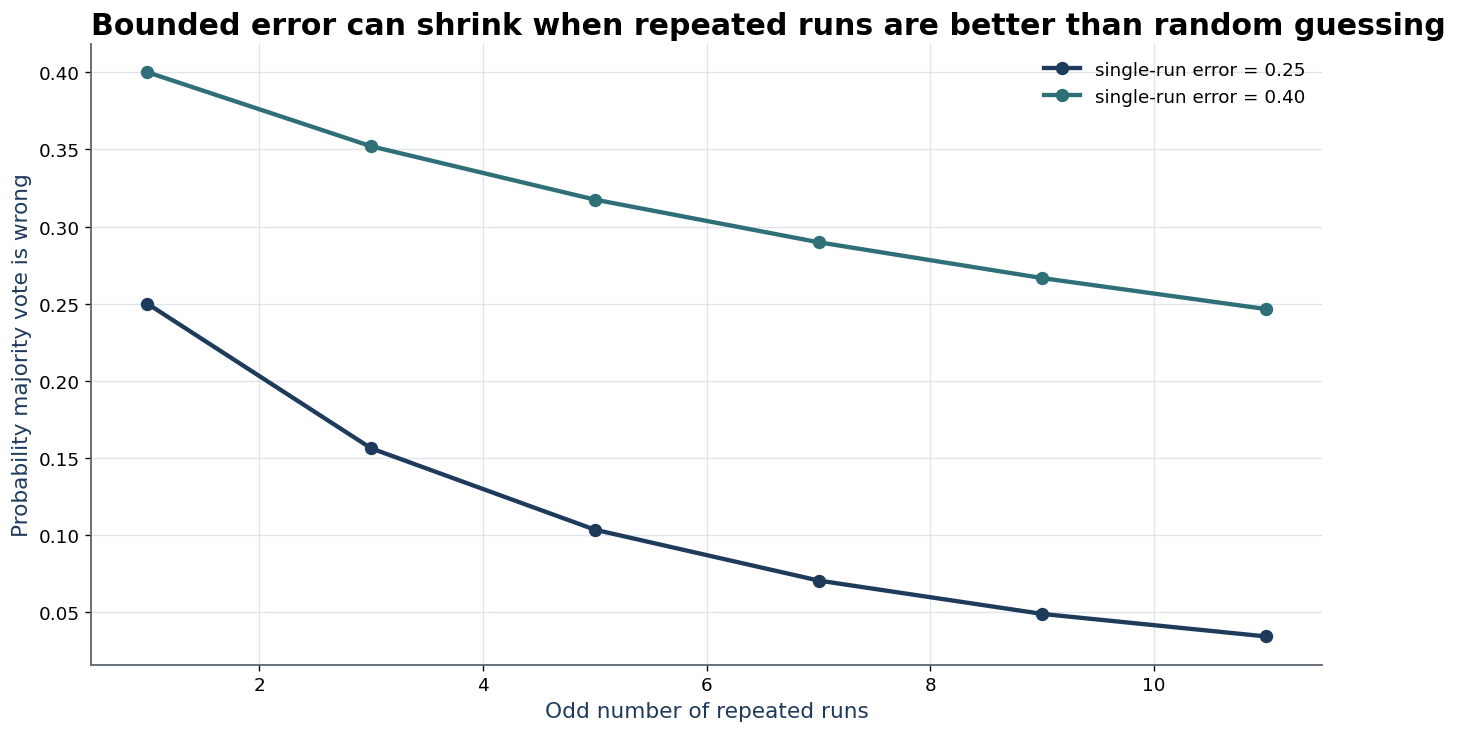

In [24]:
plot_bounded_error_amplification(
    odd_repeats,
    error_curves,
    title='Bounded error can shrink when repeated runs are better than random guessing',
)
plt.show()


In [25]:
# This table is a compact verbal summary of three computation models.
# `P` means Polynomial-time solvable and is the deterministic baseline.
# `BPP` means Bounded-error probabilistic polynomial time.
# `BQP` means Bounded-error quantum polynomial time.
# The point is to name the model, the resource it allows, and the caution
# students should remember when hearing the abbreviation.
bridge_df = pd.DataFrame(
    {
        'Class': [
            'P (Polynomial-time solvable)',
            'BPP (Bounded-error probabilistic polynomial time)',
            'BQP (Bounded-error quantum polynomial time)',
        ],
        'Resource lens': ['deterministic computation', 'randomized computation', 'quantum computation'],
        'Intuition': [
            'efficient algorithms with no randomness requirement',
            'efficient algorithms with bounded probability of error',
            'efficient quantum algorithms with bounded probability of error',
        ],
        'Caution': [
            'efficient does not mean tiny constants in practice',
            'randomness helps some problems, not all problems',
            'quantum speedups exist for some structured problems, not every hard problem',
        ],
    }
)
display_wrapped(bridge_df)


,Class,Resource lens,Intuition,Caution
0,P (Polynomial-time solvable),deterministic computation,efficient algorithms with no randomness requirement,efficient does not mean tiny constants in practice
1,BPP (Bounded-error probabilistic polynomial time),randomized computation,efficient algorithms with bounded probability of error,"randomness helps some problems, not all problems"
2,BQP (Bounded-error quantum polynomial time),quantum computation,efficient quantum algorithms with bounded probability of error,"quantum speedups exist for some structured problems, not every hard problem"


The first table names the classes. The second compares exact majority-vote error with a Monte Carlo estimate. Together, they answer two different questions: **what do these classes mean in words, and what does bounded error actually look like numerically?** That keeps the section tied to computation rather than turning it into pure terminology.


In [26]:
# Here we compare the exact formula with a simulation of the same story.
# `odd_repeats` is the number of repeated algorithm runs.
# The theory column comes from `majority_vote_error_probability`.
# The simulation column comes from `simulate_majority_vote_error`.
# If the two columns are close, students can see that the probability model
# and the executable experiment are describing the same phenomenon.
amplification_df = pd.DataFrame(
    {
        'repeats': odd_repeats,
        'theory error (p = 0.25)': [majority_vote_error_probability(0.25, int(r)) for r in odd_repeats],
        'simulation error (p = 0.25)': [simulate_majority_vote_error(0.25, int(r), trials=4000, rng=rng) for r in odd_repeats],
    }
)
display_wrapped(amplification_df)


,repeats,theory error (p = 0.25),simulation error (p = 0.25)
0,1,0.25,0.254
1,3,0.156,0.15
2,5,0.104,0.101
3,7,0.0706,0.0688
4,9,0.0489,0.0512
5,11,0.0343,0.033


In [27]:
display_wrapped(Markdown(markdown_box(
    'Randomness and quantum mechanics may move some boundaries, but they do not erase hardness. `BQP` (Bounded-error quantum polynomial time) is not a synonym for “everything difficult.”'
)))


> **Takeaway:**
> Randomness and quantum mechanics may move some boundaries, but they do not erase hardness. `BQP` (Bounded-error quantum polynomial time) is not a synonym for “everything difficult.”

In [28]:
display_wrapped(Markdown(instructor_prompt(
    'What is the difference between saying “quantum helps on some problems” and saying “quantum makes hard problems easy”?'
)))


> **Instructor Prompt:**
> What is the difference between saying “quantum helps on some problems” and saying “quantum makes hard problems easy”?

## 5. Misconceptions to avoid

**Concept question:** Which simple slogans sound plausible here but are actually misleading?


In [29]:
# Each row is one tempting but misleading slogan students often adopt.
# `claim` is the oversimplified statement.
# `correction` is the safer course-level replacement.
# `why` records the concrete reason, tied back to evidence already shown
# earlier in the notebook.
misconception_rows = [
    {
        'claim': 'Quantum computing makes all hard problems easy.',
        'correction': 'Quantum algorithms help on some structured problems, not on every hard problem.',
        'why': 'No course-appropriate evidence here supports “everything hard becomes easy.”',
    },
    {
        'claim': 'BQP (Bounded-error quantum polynomial time) means every difficult problem belongs to quantum speedup territory.',
        'correction': 'BQP (Bounded-error quantum polynomial time) names problems with efficient quantum algorithms and bounded error.',
        'why': 'It is a class with specific requirements, not a label for “hard things.”',
    },
    {
        'claim': 'If verification is cheap, search must also be cheap.',
        'correction': 'Checking one candidate can be far cheaper than discovering a good candidate.',
        'why': 'Subset-sum style search versus checking showed that directly.',
    },
    {
        'claim': 'A class label tells me practical runtime on my laptop.',
        'correction': 'Asymptotic class and real-world performance are related but different questions.',
        'why': 'Constants, data layout, and implementation details still matter.',
    },
]


Misconceptions matter because students naturally compress new ideas into slogans. This section slows that down by pairing each tempting claim with a safer course-appropriate correction.


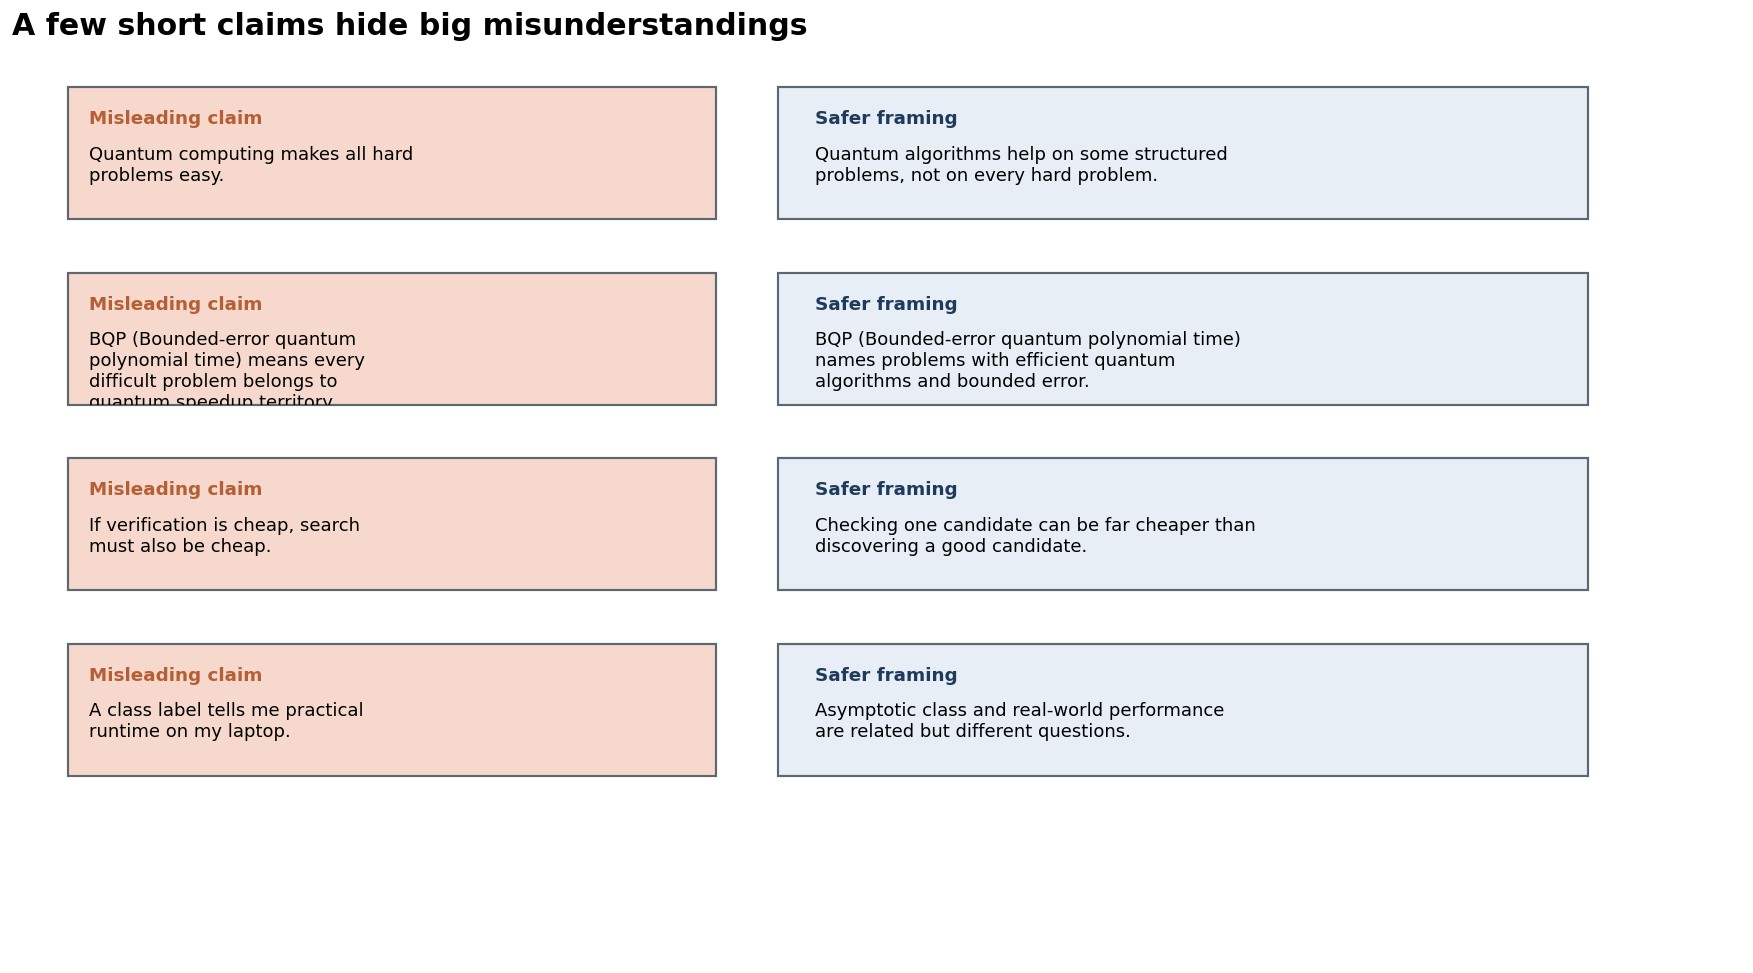

In [30]:
plot_claim_checklist(
    [{'claim': row['claim'], 'correction': row['correction']} for row in misconception_rows],
    title='A few short claims hide big misunderstandings',
)
plt.show()


These corrections are small, but they matter. Without them, students often over-interpret class names and over-promise what quantum computing can do.


In [31]:
# This DataFrame keeps the misconception records in full so they can be
# displayed as a compact reference table after the larger visual card view.
misconception_df = pd.DataFrame(misconception_rows)
display_wrapped(misconception_df)


,claim,correction,why
0,Quantum computing makes all hard problems easy.,"Quantum algorithms help on some structured problems, not on every hard problem.",No course-appropriate evidence here supports “everything hard becomes easy.”
1,BQP (Bounded-error quantum polynomial time) means every difficult problem belongs to quantum speedup territory.,BQP (Bounded-error quantum polynomial time) names problems with efficient quantum algorithms and bounded error.,"It is a class with specific requirements, not a label for “hard things.”"
2,"If verification is cheap, search must also be cheap.",Checking one candidate can be far cheaper than discovering a good candidate.,Subset-sum style search versus checking showed that directly.
3,A class label tells me practical runtime on my laptop.,Asymptotic class and real-world performance are related but different questions.,"Constants, data layout, and implementation details still matter."


The follow-up table below spells out the damage each misconception would do. That makes the corrections more than semantic; it shows how wrong framing leads to wrong predictions.


In [32]:
# This follow-up table makes each misconception more concrete.
# The first column repeats the misleading claim.
# The second column spells out the incorrect prediction a student might make
# if they believed that claim.
# The third column ties the correction back to notebook evidence stored in
# the `why` field above.
misconception_consequence_df = pd.DataFrame(
    {
        'Misleading claim': [row['claim'] for row in misconception_rows],
        'What it would wrongly predict': [
            'Every combinatorial search becomes easy once a quantum computer appears.',
            'Any problem that feels difficult should automatically be called BQP.',
            'Subset-sum search and subset-sum checking should scale about the same way.',
            'Two algorithms in the same class should feel equally fast in practice.',
        ],
        'Why notebook evidence resists that claim': [row['why'] for row in misconception_rows],
    }
)
display_wrapped(misconception_consequence_df)


,Misleading claim,What it would wrongly predict,Why notebook evidence resists that claim
0,Quantum computing makes all hard problems easy.,Every combinatorial search becomes easy once a quantum computer appears.,No course-appropriate evidence here supports “everything hard becomes easy.”
1,BQP (Bounded-error quantum polynomial time) means every difficult problem belongs to quantum speedup territory.,Any problem that feels difficult should automatically be called BQP.,"It is a class with specific requirements, not a label for “hard things.”"
2,"If verification is cheap, search must also be cheap.",Subset-sum search and subset-sum checking should scale about the same way.,Subset-sum style search versus checking showed that directly.
3,A class label tells me practical runtime on my laptop.,Two algorithms in the same class should feel equally fast in practice.,"Constants, data layout, and implementation details still matter."


In [33]:
display_wrapped(Markdown(markdown_box(
    'Careful wording is part of careful science. Complexity classes organize our reasoning, but they do not license magical claims.'
)))


> **Takeaway:**
> Careful wording is part of careful science. Complexity classes organize our reasoning, but they do not license magical claims.

In [34]:
display_wrapped(Markdown(instructor_prompt(
    'Which misconception feels most tempting after a first encounter with quantum computing, and how would you correct it in one sentence?'
)))


> **Instructor Prompt:**
> Which misconception feels most tempting after a first encounter with quantum computing, and how would you correct it in one sentence?

## 6. Recap / takeaways


In [35]:
display_wrapped(Markdown(markdown_box(
    'Some growth laws stay manageable while brute-force search spaces can explode. Verifying one candidate may be cheap even when finding it is hard. Problem classes such as P, NP, NP-hard, NP-complete, BPP, and BQP give us a disciplined language for these differences, but none of them means that every hard problem becomes easy.',
    title='Recap'
)))


> **Recap:**
> Some growth laws stay manageable while brute-force search spaces can explode. Verifying one candidate may be cheap even when finding it is hard. Problem classes such as P, NP, NP-hard, NP-complete, BPP, and BQP give us a disciplined language for these differences, but none of them means that every hard problem becomes easy.

## 7. Questions for students

- Why can a problem have cheap verification but expensive search?
- What is the difference between polynomial growth and exponential growth in practical terms?
- Why is `NP` not the same thing as “impossible”?
- Why is `BQP` not a synonym for “all hard problems on a quantum computer”?
- Which visual in this notebook most clearly showed you where brute force stops being realistic?
